# Statistical Analysis

## Objective

The objective of this phase is to validate whether key customer characteristics differ significantly between churned and retained customers using statistical testing.

This analysis focuses on:

- Monthly Charges
- Customer Tenure

The results will help determine whether observed differences are statistically significant rather than occurring by chance.

In [1]:
%pip install seaborn

In [2]:
# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ============================
# Load Dataset
# ============================

df = pd.read_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_cleaned.csv"
)

df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


# Monthly Charges Statistical Analysis

This section evaluates whether monthly charges differ significantly between churned and retained customers.

In [3]:
churned = df[df["Churn Value"] == 1]["Monthly Charges"]

retained = df[df["Churn Value"] == 0]["Monthly Charges"]

t_stat, p_value = ttest_ind(
    churned,
    retained
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", p_value)

T-Statistic: 16.4796
P-Value: 6.760843117980302e-60


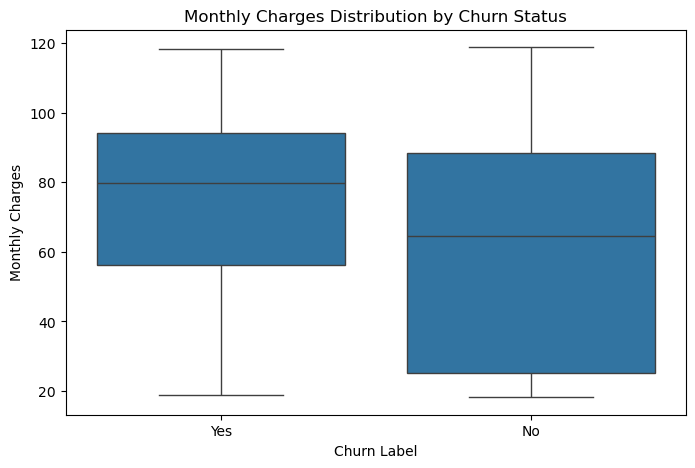

In [4]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges Distribution by Churn Status")

plt.show()

### Insight

The T-test results indicate a statistically significant difference in monthly charges between churned and retained customers (p < 0.001).

Customers who churned paid significantly higher monthly fees than retained customers, suggesting that pricing may contribute to customer attrition.

# Customer Tenure Statistical Analysis

This section evaluates whether customer tenure differs significantly between churned and retained customers.

In [5]:
churned_tenure = df[df["Churn Value"] == 1]["Tenure Months"]

retained_tenure = df[df["Churn Value"] == 0]["Tenure Months"]

t_stat, p_value = ttest_ind(
    churned_tenure,
    retained_tenure
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", p_value)

T-Statistic: -31.7413
P-Value: 9.437650217574845e-207


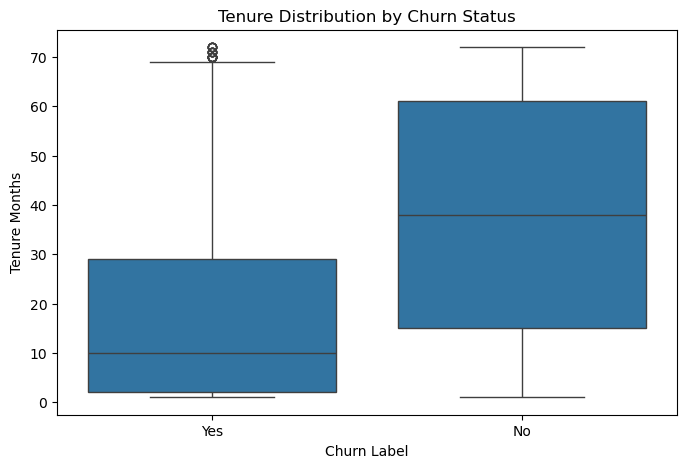

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn Status")

plt.show()

### Insight

The T-test results indicate a statistically significant difference in customer tenure between churned and retained customers (p < 0.001).

Customers who churned had substantially shorter tenures, confirming that newer customers are considerably more likely to leave the company.

# Correlation Analysis

This section explores relationships between numerical variables and customer churn.

In [7]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Value",
    "CLTV",
    "Churn Score"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix.round(2)

,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV,Churn Score
Tenure Months,1.00,0.25,0.83,-0.35,0.40,-0.23
Monthly Charges,0.25,1.00,0.65,0.19,0.10,0.13
Total Charges,0.83,0.65,1.00,-0.20,0.34,-0.12
Churn Value,-0.35,0.19,-0.20,1.00,-0.13,0.66
CLTV,0.40,0.10,0.34,-0.13,1.00,-0.08
Churn Score,-0.23,0.13,-0.12,0.66,-0.08,1.00


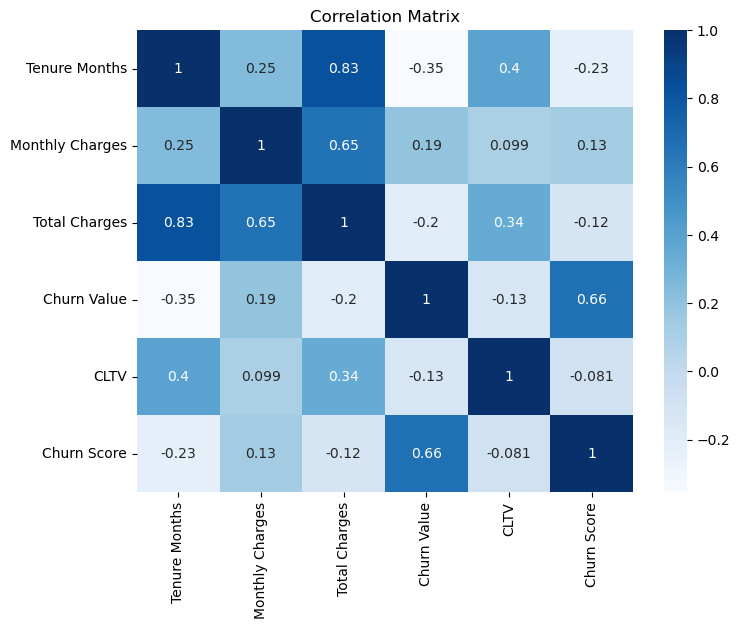

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

# Statistical Findings

The statistical analysis confirms that customer churn is strongly associated with both customer tenure and monthly charges.

T-tests revealed highly significant differences between churned and retained customers for both variables (p < 0.001).

Key findings include:

- Customers who churned paid significantly higher monthly charges.
- Customers who churned had substantially shorter tenures.
- Customer tenure shows a moderate negative correlation with churn (-0.35), indicating that longer-tenured customers are less likely to leave.
- Monthly charges show a positive relationship with churn (0.19), suggesting that higher service costs may contribute to customer attrition.
- Churn Score demonstrates the strongest positive correlation with churn (0.66), validating its predictive value.

Overall, the results indicate that customer retention is heavily influenced by customer lifecycle stage, pricing structure, and overall service commitment.